# PopOut — Adversarial Search Strategies
**Artificial Intelligence 2025/2026** | DCC – FCUP

PopOut is a variant of Connect-4 where players can also remove a disc
from the bottom of a column (pop move), shifting all pieces above it
down by one row. The first player to connect four discs wins.

**Group members**
- Daniel Viloria Prieto
- Isaac Morales Santana
- Jan Henzl

---

## 1. Imports

In [ ]:
from src.game.board import Board, PLAYER1, PLAYER2

from src.game.player import (
    HumanPlayer, RandomPlayer,
    MCTSPlayer, MCTSPlayerV2, MCTSPlayerV3,
    MCTSPlayerV4, MCTSPlayerV5, MCTSPlayerV6, DecisionTreePlayer
)

from src.game.game import Game
from src.decision_tree.id3 import ID3DecisionTree
from src.decision_tree.tree import DecisionTreeNode
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for headless execution
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Game Overview

The board is a 6×7 grid. Each turn a player can:
- **Drop** — place a disc into a column from the top
- **Pop** — remove their own disc from the bottom of a column

Three additional rules handle edge cases:
- If a pop creates four-in-a-row for both players, the player who popped wins
- If the board is full and a player can pop, they may declare a draw instead
- If the same state repeats three times, either player may claim a draw

The pop move is what makes PopOut strategically richer than standard Connect-4:
it allows players to undo threats, create new ones, and manipulate the board
state in ways that are hard to anticipate several moves ahead.

## 3. Human vs Human

The following cell allows two human players to play interactively in a terminal.
It is commented out to allow the notebook to run non-interactively.

In [2]:
# Uncomment to play Human vs Human (interactive session only)
# player1 = HumanPlayer(PLAYER1)
# player2 = HumanPlayer(PLAYER2)

# game = Game(player1, player2)

# game.play()

## 4. Human vs Computer (MCTS)

The MCTS algorithm builds a search tree by iterating four phases:
1. **Selection** — descend using UCT to find a promising node
2. **Expansion** — expand one untried move
3. **Simulation** — play out a random game from that node
4. **Backpropagation** — update win/visit counts up the tree

The UCT formula balances exploitation (choosing moves with high win rates)
and exploration (trying less-visited moves):

$$UCT = \frac{w_i}{n_i} + C \sqrt{\frac{\ln N}{n_i}}$$

where $w_i$ is wins, $n_i$ is visits for child $i$, $N$ is visits for the parent,
and $C = \sqrt{2}$ is the exploration constant.

Six variants are available, differing in simulation strategy,
final move selection (max visits vs max wins), and tree reuse.

| Version | Simulation | Final selection | Tree reuse |
|---------|-----------|----------------|------------|
| V1 | Random | Max visits | No |
| V2 | Random | Max visits | Yes |
| V3 | Smart | Max visits | No |
| V4 | Random | Max wins | No |
| V5 | Random | Max wins | Yes |
| V6 | Smart | Max wins | No |

The **smart simulation** heuristic immediately takes a winning move if available,
or blocks an opponent winning drop move, before falling back to random play.

In [3]:
# Uncomment to play Human vs Computer (interactive session only)
# player1 = HumanPlayer(PLAYER1)
# player2 = MCTSPlayerV3(PLAYER2, iterations=2000)
# 
# game = Game(player1, player2)
# 
# game.play()

## 5. Computer vs Computer (MCTS versions)

We pit two MCTS variants against each other to observe how the improvements
affect play. V1 uses pure random rollouts while V6 combines smart simulation
with max-wins final selection — the strongest variant.

In [4]:
player1 = MCTSPlayer(PLAYER1, iterations=500)
player2 = MCTSPlayerV6(PLAYER2, iterations=500)

game = Game(player1, player2)

game.play()

=== PopOut Game Start ===
-------
-------
-------
-------
-------
-------

 MCTSPlayer-X plays: ('drop', 6)
-------
-------
-------
-------
-------
------X

 MCTSPlayerV6-O plays: ('drop', 6)
-------
-------
-------
-------
------O
------X

 MCTSPlayer-X plays: ('drop', 6)
-------
-------
-------
------X
------O
------X

 MCTSPlayerV6-O plays: ('drop', 3)
-------
-------
-------
------X
------O
---O--X

 MCTSPlayer-X plays: ('drop', 3)
-------
-------
-------
------X
---X--O
---O--X

 MCTSPlayerV6-O plays: ('drop', 5)
-------
-------
-------
------X
---X--O
---O-OX

 MCTSPlayer-X plays: ('drop', 3)
-------
-------
-------
---X--X
---X--O
---O-OX

 MCTSPlayerV6-O plays: ('drop', 4)
-------
-------
-------
---X--X
---X--O
---OOOX

 MCTSPlayer-X plays: ('drop', 2)
-------
-------
-------
---X--X
---X--O
--XOOOX

 MCTSPlayerV6-O plays: ('drop', 2)
-------
-------
-------
---X--X
--OX--O
--XOOOX

 MCTSPlayer-X plays: ('drop', 3)
-------
-------
---X---
---X--X
--OX--O
--XOOOX

 MCTSPlayerV6

1

## 6. Dataset Generation

The MCTS algorithm builds a search tree by iterating four phases:
1. **Selection** - descend using UCT to find a promising node
2. **Expansion** - expand one untried move
3. **Simulation** - play out a random game from that node
4. **Backpropagation** - update win/visit counts up the tree

### Why we built six variants

Pure MCTS works, but it has well-known weaknesses we wanted to address. Each variant changes **one** part of the standard algorithm so we can isolate the effect of each idea.

| Version | Simulation | Final selection | Tree reuse |
|---------|-----------|----------------|------------|
| V1 | Random | Max visits | No |
| V2 | Random | Max visits | Yes |
| V3 | Smart | Max visits | No |
| V4 | Random | Max wins | No |
| V5 | Random | Max wins | Yes |
| V6 | Smart | Max wins | No |

#### V2 - Tree reuse
**What it changes:** instead of throwing away the search tree after each move, V2 keeps the subtree rooted at the position the game actually reached.
**Why it should help:** the simulations from the previous turn already explored many of the same positions. Reusing the tree means later turns start with thousands of "free" visits already accumulated, so the same iteration budget produces stronger play as the game progresses.

#### V3 - Smart simulation
**What it changes:** during the simulation rollout (step 3), instead of picking moves purely at random, V3 always takes an immediate win when available and always blocks the opponent's immediate winning drop.
**Why it should help:** pure random rollouts often miss obvious tactical moves, so the simulated games don't reflect realistic play. A simulated opponent who never takes a winning move makes the algorithm underestimate threats. Smart simulation makes the rollouts more realistic, which makes the win/loss statistics propagated back up the tree more informative.

#### V4, V5, V6 - Max-wins final selection
**What they change:** all three replace the default "max visits" final move choice with "max wins" (which is mathematically equivalent to winrate * visits). V4 applies this on top of plain V1; V5 combines it with V2's tree reuse; V6 combines it with V3's smart simulation.
**Why it should help:** max-visits is the safe "robust child" pick but it ignores the quality of the explorations. If two children were visited equally but one has a much higher winrate, max-wins picks the better one. It rewards children that are both frequently visited and high-quality. We expect V6 to be the strongest overall, because smart simulation produces more reliable winrates per child and max-wins exploits exactly that signal - at the cost of being noticeably slower per move.


In [ ]:
player1 = HumanPlayer(PLAYER1)
player2 = MCTSPlayer(PLAYER2, iterations=10000)

# generate_dataset(100, "data/d4.csv", 100)
# df = pd.read_csv("data/d4.csv")

# print(f"Total samples: {len(df)}")
# print(f"Drop moves: {(df['move_type'] == 'drop').sum()}")
# print(f"Pop moves:  {(df['move_type'] == 'pop').sum()}")

# df.head()

## 7. Decision Tree (ID3)

The ID3 procedure builds a decision tree by recursively selecting the attribute
that maximises **information gain** (entropy reduction) at each node.

$$\text{Gain}(S, A) = H(S) - \sum_{v \in A} \frac{|S_v|}{|S|} H(S_v)$$

where $H(S) = -\sum_c p_c \log_2 p_c$ is the entropy of set $S$.

For continuous/numerical attributes we find the optimal split threshold
by exhaustive search over all midpoints between consecutive distinct values.
For the PopOut board (values 0, 1, 2) this means trying thresholds 0.5 and 1.5
per cell — 84 candidate splits evaluated at every node.

### 7.1 Dataset 1 - Iris (warm-up)

We first validate our ID3 implementation on the classic Iris dataset.
It has 4 continuous features (sepal/petal length and width) and 3 classes.
This is a well-understood benchmark that lets us verify correctness before
applying the tree to the more complex PopOut domain.

In [6]:
player1 = MCTSPlayerV6(PLAYER1, iterations=2000)
player2 = MCTSPlayer(PLAYER2, iterations=2000)

print(f'Iris dataset: {len(X_iris)} samples, {len(iris_features)} features')
print('Features:', iris_features)
print('Classes:', sorted(set(y_iris)))

df = pd.DataFrame(X_iris, columns=iris_features)
df['class'] = y_iris
df.describe()

In [7]:
# Train / test split (80 / 20)
import random
random.seed(42)
indices = list(range(len(X_iris)))
random.shuffle(indices)
split = int(0.8 * len(indices))

X_train = [X_iris[i] for i in indices[:split]]
y_train = [y_iris[i] for i in indices[:split]]
X_test  = [X_iris[i] for i in indices[split:]]
y_test  = [y_iris[i] for i in indices[split:]]

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')

Train: 120 samples  |  Test: 30 samples


In [8]:
# Build the ID3 decision tree (all four features are continuous)
iris_tree = ID3DecisionTree(
    continuous_features=list(range(4)),
    feature_names=iris_features,
)
iris_tree.fit(X_train, y_train)

print('=== Iris Decision Tree ===')
iris_tree.display()

train_eval = iris_tree.evaluate(X_train, y_train)
test_eval  = iris_tree.evaluate(X_test,  y_test)
print(f'\nTrain accuracy: {train_eval["accuracy"]:.2%}  ({train_eval["correct"]}/{train_eval["total"]})')
print(f'Test  accuracy: {test_eval["accuracy"]:.2%}  ({test_eval["correct"]}/{test_eval["total"]})')

=== Iris Decision Tree ===
[petal_length <= 2.4500?]
  No:
    [petal_width <= 1.7500?]
      No:
        → Iris-virginica
      Yes:
        [sepal_length <= 4.9500?]
          No:
            [sepal_width <= 2.8500?]
              No:
                → Iris-versicolor
              Yes:
                → Iris-versicolor
          Yes:
            → Iris-virginica
  Yes:
    → Iris-setosa


Train accuracy: 97.50%  (117/120)
Test  accuracy: 90.00%  (27/30)


In [9]:
# Effect of max_depth on Iris accuracy
depths = [1, 2, 3, 4, 5, None]
train_accs, test_accs = [], []

for d in depths:
    t = ID3DecisionTree(continuous_features=list(range(4)), max_depth=d)
    t.fit(X_train, y_train)
    train_accs.append(t.evaluate(X_train, y_train)['accuracy'])
    test_accs.append(t.evaluate(X_test,   y_test)['accuracy'])

depth_labels = [str(d) if d is not None else 'None' for d in depths]
x = range(len(depths))

plt.figure(figsize=(8, 4))
plt.plot(x, train_accs, marker='o', label='Train')
plt.plot(x, test_accs,  marker='s', label='Test')
plt.xticks(x, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Iris — Effect of max_depth on ID3 accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iris_depth.png', dpi=80)
plt.show()
plt.close()
print('Plot saved to iris_depth.png')

Plot saved to iris_depth.png


/tmp/ipykernel_45027/770553187.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Performance Evaluation

We measure three things:
1. **MCTS head-to-head** - which variant is strongest? (running real games)
2. **Decision tree accuracy** - how well does the ID3 tree predict moves on held-out data?
3. **DecisionTreePlayer vs MCTS** - does the tree translate into actual playing strength?


In [4]:
from src.game.evaluator import (
    evaluate_mcts,
    evaluate_tree_accuracy,
    evaluate_tree_player,
)
import matplotlib.pyplot as plt


### 7.1 MCTS Head-to-Head

For each matchup we run several games and count wins / draws / losses.


In [ ]:
mcts_results = evaluate_mcts(num_games=10, iterations=2000)

# Overall ranking - answer to "which MCTS is best?"
ranking_df = pd.DataFrame(mcts_results["totals"])
ranking_df



MCTSPlayer (P1) vs MCTSPlayerV2 (P2)
  Game 1/10: P1
  Game 2/10: P1
  Game 3/10: P1
  Game 4/10: P2
  Game 5/10: P1
  Game 6/10: P1
  Game 7/10: P1
  Game 8/10: P2
  Game 9/10: P1
  Game 10/10: P1

MCTSPlayer (P1) vs MCTSPlayerV3 (P2)
  Game 1/10: P2
  Game 2/10: P1
  Game 3/10: P2
  Game 4/10: P2
  Game 5/10: P1
  Game 6/10: P1
  Game 7/10: P2
  Game 8/10: P2
  Game 9/10: P2
  Game 10/10: P2

MCTSPlayer (P1) vs MCTSPlayerV4 (P2)
  Game 1/10: P2
  Game 2/10: P1
  Game 3/10: P2
  Game 4/10: P2
  Game 5/10: P1
  Game 6/10: P1
  Game 7/10: P2
  Game 8/10: P2
  Game 9/10: P1
  Game 10/10: P1

MCTSPlayer (P1) vs MCTSPlayerV5 (P2)
  Game 1/10: P1
  Game 2/10: P2
  Game 3/10: P1
  Game 4/10: P1
  Game 5/10: P1
  Game 6/10: P1
  Game 7/10: P1
  Game 8/10: P1
  Game 9/10: P1
  Game 10/10: P1

MCTSPlayer (P1) vs MCTSPlayerV6 (P2)
  Game 1/10: P2
  Game 2/10: P2
  Game 3/10: P1
  Game 4/10: P2
  Game 5/10: P1
  Game 6/10: P2
  Game 7/10: P2
  Game 8/10: P2
  Game 9/10: P2
  Game 10/10: P1

MCTS

,player,wins,draws,losses,games,winrate
0,MCTSPlayerV3,66,0,34,100,0.66
1,MCTSPlayerV6,65,0,35,100,0.65
2,MCTSPlayer,46,0,54,100,0.46
3,MCTSPlayerV4,45,1,54,100,0.45
4,MCTSPlayerV2,40,1,59,100,0.40
5,MCTSPlayerV5,37,0,63,100,0.37


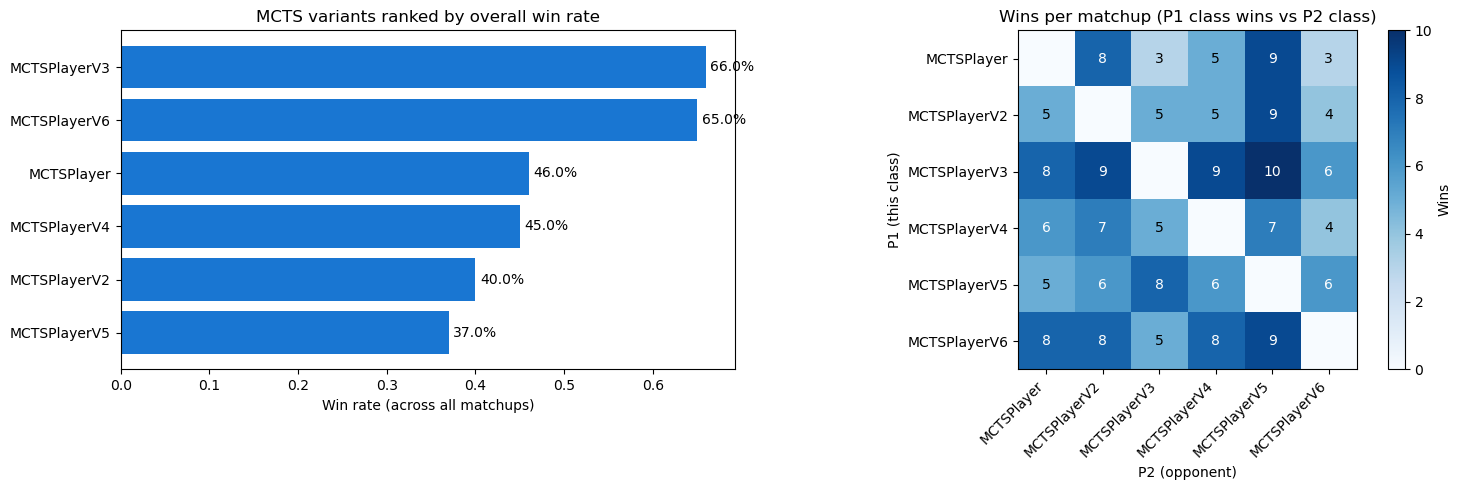

,p1_name,p2_name,p1_wins,draws,p2_wins,p1_winrate
0,MCTSPlayer,MCTSPlayerV2,8,0,2,0.8
1,MCTSPlayer,MCTSPlayerV3,3,0,7,0.3
2,MCTSPlayer,MCTSPlayerV4,5,0,5,0.5
3,MCTSPlayer,MCTSPlayerV5,9,0,1,0.9
4,MCTSPlayer,MCTSPlayerV6,3,0,7,0.3
5,MCTSPlayerV2,MCTSPlayer,5,0,5,0.5
6,MCTSPlayerV2,MCTSPlayerV3,5,0,5,0.5
7,MCTSPlayerV2,MCTSPlayerV4,5,1,4,0.5
8,MCTSPlayerV2,MCTSPlayerV5,9,0,1,0.9
9,MCTSPlayerV2,MCTSPlayerV6,4,0,6,0.4


In [7]:
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: ranking bar chart ---
ax1.barh(ranking_df["player"], ranking_df["winrate"], color="#1976d2")
ax1.set_xlabel("Win rate (across all matchups)")
ax1.set_title("MCTS variants ranked by overall win rate")
ax1.invert_yaxis()
for i, (p, w) in enumerate(zip(ranking_df["player"], ranking_df["winrate"])):
    ax1.text(w + 0.005, i, f"{w:.1%}", va="center")

# --- Right: win matrix heatmap (row = P1 class, col = P2 class) ---
wm = mcts_results["win_matrix"]
names = list(wm.keys())
matrix = np.array([[wm[r][c] for c in names] for r in names])

im = ax2.imshow(matrix, cmap="Blues")
ax2.set_xticks(range(len(names)))
ax2.set_yticks(range(len(names)))
ax2.set_xticklabels(names, rotation=45, ha="right")
ax2.set_yticklabels(names)
ax2.set_xlabel("P2 (opponent)")
ax2.set_ylabel("P1 (this class)")
ax2.set_title("Wins per matchup (P1 class wins vs P2 class)")
for i in range(len(names)):
    for j in range(len(names)):
        if i != j:
            ax2.text(j, i, int(matrix[i][j]), ha="center", va="center",
                     color="white" if matrix[i][j] > matrix.max() / 2 else "black")
plt.colorbar(im, ax=ax2, label="Wins")

plt.tight_layout()
plt.show()

# Detailed per-matchup breakdown
pd.DataFrame(mcts_results["matchups"])


### 7.1.1 Review of the results

**Smart simulation is the dominant factor.** V3 (66%) and V6 (65%) finish far ahead of every other variant. This confirms the design hypothesis from section 4: random rollouts produce noisy, unrealistic win/loss statistics because the simulated opponent often misses obvious winning moves. Once the rollouts always take an immediate win and block an immediate threat, the values propagated back through the tree become much more informative, and UCT can actually distinguish good moves from bad ones.

**Max-wins selection has almost no effect on its own.** V4 (45%) is essentially tied with V1 (46%), and V6 is essentially tied with V3. Switching the final pick from "most visits" to "most wins" doesn't change the answer in practice because UCT already steers visits toward high-value children, so the two criteria almost always agree. The change is a refinement, not a fundamental fix.

**Tree reuse hurts here.** V2 (40%) and V5 (37%) finish at the bottom, below the variants without tree reuse. This is counter-intuitive but consistent: when the search tree from a previous turn is carried over, it brings inflated visit counts that suppress UCT's exploration term, so new iterations are diluted against stale statistics from earlier positions. The algorithm over-exploits paths that looked good two turns ago instead of re-evaluating the current position. The fact that *both* tree-reuse variants land below the no-reuse versions makes this look like a real effect, not just noise from a single matchup.

**Statistical caveat.** Each class plays 100 games, so the standard error on a winrate is roughly +-5%. Differences smaller than that (V1 vs V4, V3 vs V6) should be treated as noise; the gaps between the smart-sim group, the middle group, and the tree-reuse group are large enough to be real.

**Speed cost of smart simulation.** The strength of V3 and V6 comes at a real price: smart simulation is noticeably slower per move than random simulation. Each rollout step copies the board and runs a win/block check for every available move, multiplied by every rollout step and every MCTS iteration. So although V3/V6 win more games at the *same iteration count*, they take far longer per move in wall-clock time. For interactive play, V3/V6 with a lower iteration budget is a reasonable middle ground; for offline analysis where time is not a constraint, the full iteration budget of V3/V6 is the strongest option.

**Verdict.** Smart simulation is the change that matters. Tree reuse as implemented here is a net negative and would need to be redesigned (e.g. visit-count rescaling) to be useful. For deployment we would pick **V3 or V6** as the strongest variants, balancing strength against the per-move time cost.


### 7.2 Decision Tree Accuracy

Splits the dataset 80% train / 20% test, trains a PopOut ID3 tree on the training set, and measures exact-move accuracy on the held-out test set.


In [13]:
tree_eval = evaluate_tree_accuracy("data/dataset.csv", test_ratio=0.2)
print(f"Train size: {tree_eval['train_size']}")
print(f"Test size:  {tree_eval['test_size']}")
print(f"Accuracy:   {tree_eval['accuracy']:.1%}")


Train size: 2386
Test size:  597
Accuracy:   14.1%


#### Visualising the tree

The trained tree (first few levels â€" full tree can be very deep).


In [14]:
tree_eval["tree"].print_tree()


attr_41 <= 0.500?
    YES: attr_35 <= 0.500?
        YES: attr_36 <= 0.500?
            YES: attr_37 <= 0.500?
                YES: attr_33 <= 1.500?
                    YES: attr_39 <= 0.500?
                        YES: attr_31 <= 0.500?
                            YES: attr_38 <= 0.500?
                                YES: attr_40 <= 1.500?
                                    YES: attr_40 <= 0.500?
                                        YES: -> [drop_6]
                                        NO:  -> [drop_5]
                                    NO:  -> [drop_0]
                                NO:  attr_40 <= 1.500?
                                    YES: attr_38 <= 1.500?
                                        YES: attr_40 <= 0.500?
                                            YES: -> [drop_3]
                                            NO:  -> [drop_6]
                                        NO:  -> [drop_0]
                                    NO:  attr_33 <= 0.500?
             

### 7.3 DecisionTreePlayer vs MCTS

The trained tree player plays against several MCTS variants. This shows whether the tree generalises to real game positions, not just held-out dataset rows.


In [ ]:
dt_results = evaluate_tree_player("data/dataset.csv", num_games=5, iterations=200)
dt_df = pd.DataFrame(dt_results)[["matchup", "p1_wins", "draws", "p2_wins", "p1_winrate"]]
dt_df


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [r["matchup"] for r in dt_results]
p1 = [r["p1_wins"] for r in dt_results]
draws = [r["draws"] for r in dt_results]
p2 = [r["p2_wins"] for r in dt_results]

ax.barh(labels, p1, label="Tree wins", color="#4caf50")
ax.barh(labels, draws, left=p1, label="Draws", color="#9e9e9e")
ax.barh(labels, p2, left=[a + b for a, b in zip(p1, draws)], label="MCTS wins", color="#e53935")
ax.set_xlabel("Games")
ax.set_title("DecisionTreePlayer vs MCTS variants")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 7.4 Play against the trained tree yourself

```python
from src.game.player import HumanPlayer, DecisionTreePlayer
from src.game.game import Game

tree_player = DecisionTreePlayer(PLAYER2, csv_path="data/dataset.csv")
Game(HumanPlayer(PLAYER1), tree_player).play()
```
